In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import  DecisionTreeRegressor


In [2]:
dataset=pd.read_csv("dados/carro.csv")

In [3]:
dataset.head(3)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2


In [4]:
dataset.shape

(19237, 18)

In [5]:
dataset.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [6]:
dataset.dtypes

ID                    int64
Price                 int64
Levy                    str
Manufacturer            str
Model                   str
Prod. year            int64
Category                str
Leather interior        str
Fuel type               str
Engine volume           str
Mileage                 str
Cylinders           float64
Gear box type           str
Drive wheels            str
Doors                   str
Wheel                   str
Color                   str
Airbags               int64
dtype: object

In [7]:
dataset.nunique()

ID                  18924
Price                2315
Levy                  559
Manufacturer           65
Model                1590
Prod. year             54
Category               11
Leather interior        2
Fuel type               7
Engine volume         107
Mileage              7687
Cylinders              13
Gear box type           4
Drive wheels            3
Doors                   3
Wheel                   2
Color                  16
Airbags                17
dtype: int64

In [8]:
colunas_categoricas=dataset.select_dtypes(include='object').columns

C:\Users\Utilizador\AppData\Local\Temp\ipykernel_1116\722376969.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas=dataset.select_dtypes(include='object').columns


In [9]:
for coluna in colunas_categoricas:
    le=LabelEncoder()
    dataset[coluna]=le.fit_transform(dataset[coluna].astype(str))

In [10]:
dataset.dtypes

ID                    int64
Price                 int64
Levy                  int64
Manufacturer          int64
Model                 int64
Prod. year            int64
Category              int64
Leather interior      int64
Fuel type             int64
Engine volume         int64
Mileage               int64
Cylinders           float64
Gear box type         int64
Drive wheels          int64
Doors                 int64
Wheel                 int64
Color                 int64
Airbags               int64
dtype: object

In [11]:
corelacao=dataset.corr()

<Axes: >

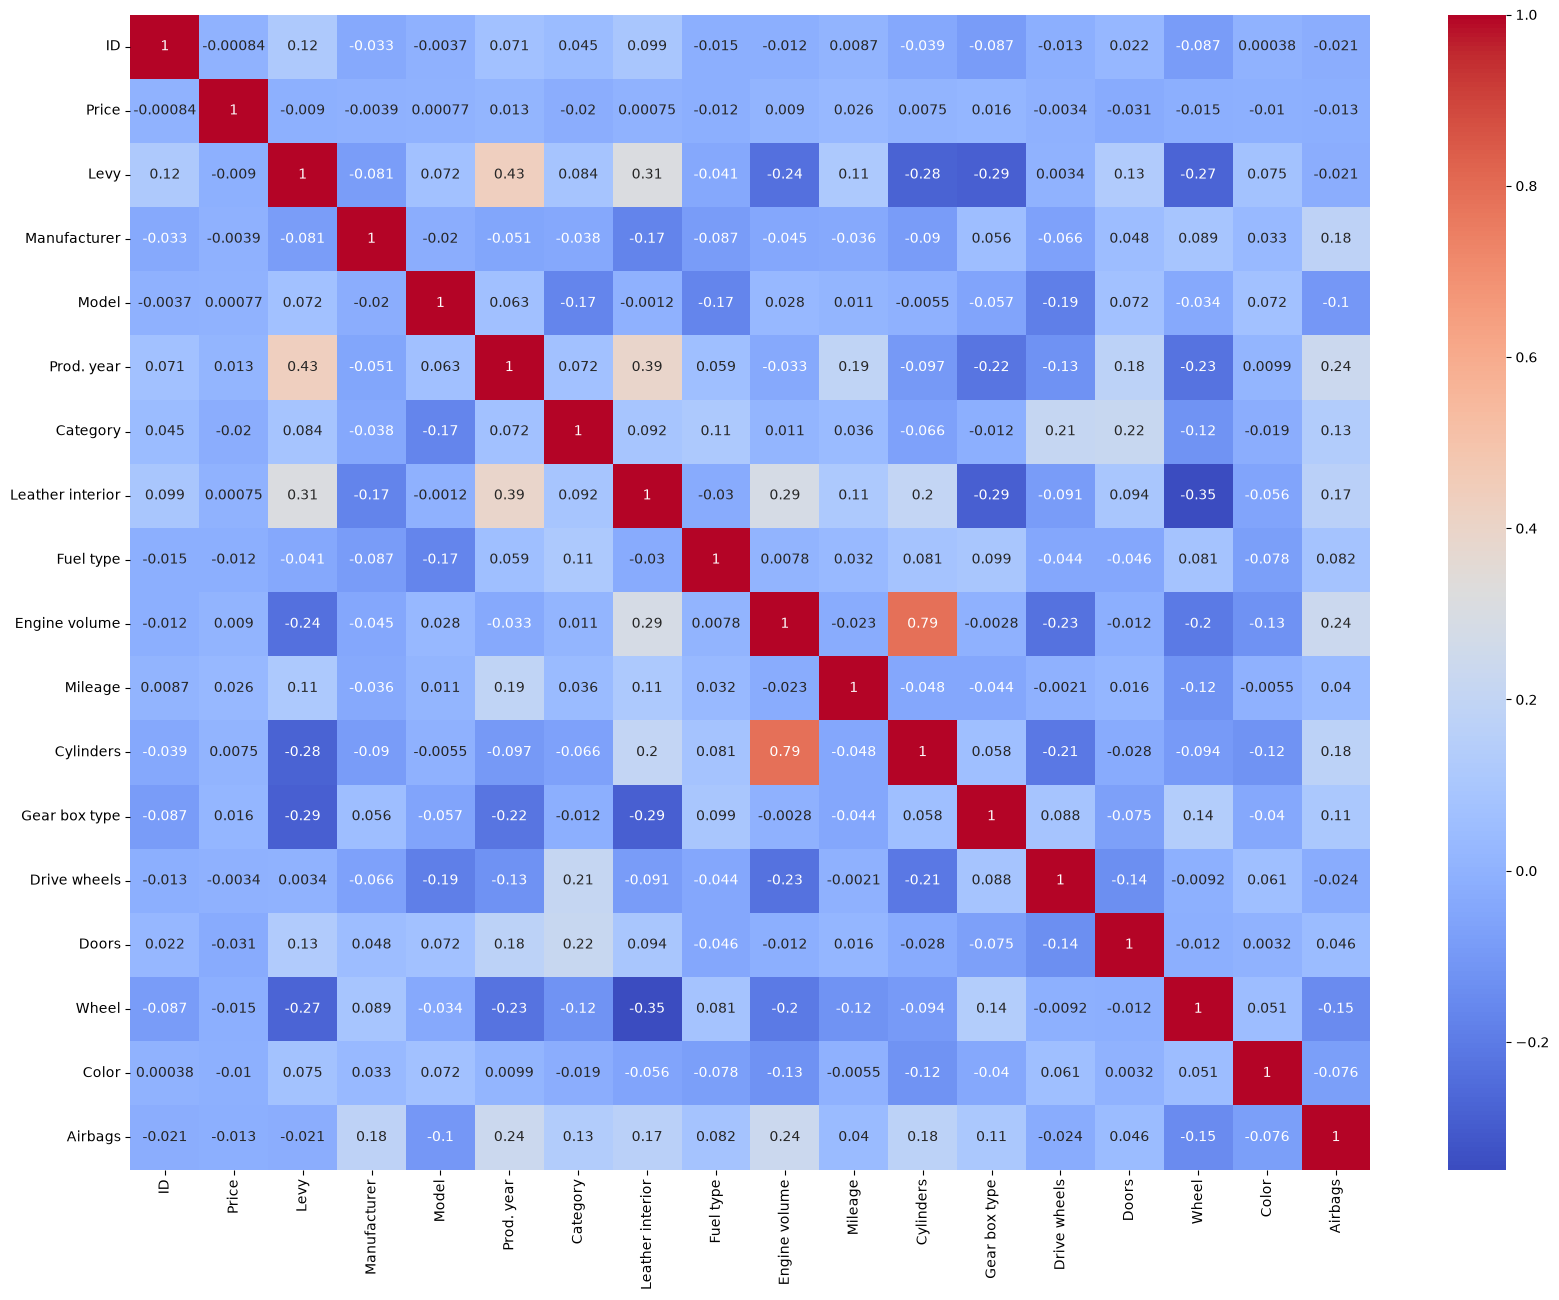

In [12]:
plt.figure(figsize=(20,15))
sns.heatmap(corelacao, annot=True, cmap="coolwarm")

In [13]:
import sweetviz as sv


relatorio = sv.analyze(dataset )

relatorio.show_html("relatorio_analise.html")

                                             |          | [  0%]   00:00 -> (? left)

findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfont: Failed to find font weight normal for Roboto, now using 500.
findfo

Report relatorio_analise.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [14]:
dataset.index

RangeIndex(start=0, stop=19237, step=1)

In [16]:
dataset.describe()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,235.856578,33.080678,862.592348,2010.912824,6.265582,0.725373,3.432396,41.462234,3364.284712,4.582991,0.536310,0.908874,0.966263,0.077143,7.776005,6.582627
std,9.365914e+05,1.905813e+05,217.603981,17.766465,410.812287,5.668673,2.790570,0.446338,1.807388,15.315334,2248.004443,1.199933,0.896607,0.567875,0.214264,0.266825,5.363884,4.320168
min,2.074688e+07,1.000000e+00,0.000000,0.000000,0.000000,1939.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.569837e+07,5.331000e+03,0.000000,21.000000,537.000000,2009.000000,4.000000,0.000000,2.000000,32.000000,1482.000000,4.000000,0.000000,1.000000,1.000000,0.000000,1.000000,4.000000
50%,4.577231e+07,1.317200e+04,207.000000,32.000000,834.000000,2012.000000,7.000000,1.000000,5.000000,36.000000,3140.000000,4.000000,0.000000,1.000000,1.000000,0.000000,7.000000,6.000000
75%,4.580204e+07,2.207500e+04,458.000000,54.000000,1226.000000,2015.000000,9.000000,1.000000,5.000000,46.000000,5104.000000,4.000000,1.000000,1.000000,1.000000,0.000000,12.000000,12.000000
max,4.581665e+07,2.630750e+07,558.000000,64.000000,1589.000000,2020.000000,10.000000,1.000000,6.000000,106.000000,7686.000000,16.000000,3.000000,2.000000,2.000000,1.000000,15.000000,16.000000


In [17]:
dataset.columns

Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='str')

In [18]:
dataset.drop(["ID","Drive wheels","Doors","Color","Levy","Leather interior","Wheel"], axis=1, inplace=True)

In [20]:
dataset.drop("Manufacturer", axis=1, inplace=True)

In [22]:
dataset.drop("Airbags", inplace=True, axis=1)

In [23]:
dataset

,Price,Model,Prod. year,Category,Fuel type,Engine volume,Mileage,Cylinders,Gear box type
0,13328,1242,2010,4,2,63,2838,6.0,0
1,16621,658,2011,4,5,56,2960,6.0,2
2,8467,684,2006,3,5,22,3140,4.0,3
3,3607,661,2011,4,2,46,2413,4.0,0
4,11726,684,2014,3,5,22,7396,4.0,0
...,...,...,...,...,...,...,...,...,...
19232,8467,385,1999,1,0,37,4394,4.0,1
19233,15681,1334,2011,9,5,44,2214,4.0,2
19234,26108,1442,2010,4,1,36,638,4.0,0
19235,5331,456,2007,4,1,36,5612,4.0,0


<Axes: >

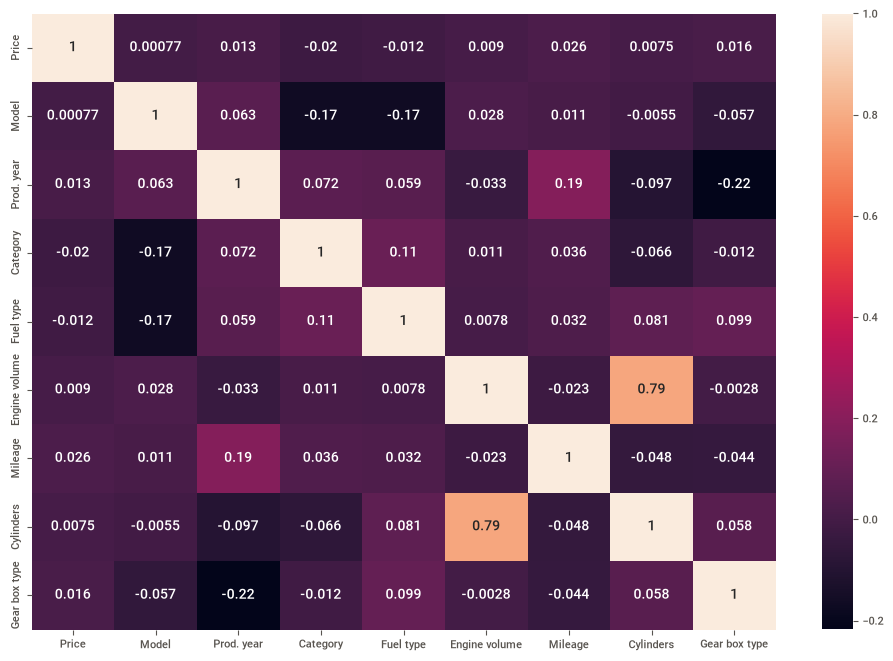

In [24]:
cor=dataset.corr()
plt.figure(figsize=(12,8))
sns.heatmap(cor, annot=True)

In [26]:
dataset.shape

(19237, 9)

In [25]:
dataset.nunique()

Price            2315
Model            1590
Prod. year         54
Category           11
Fuel type           7
Engine volume     107
Mileage          7687
Cylinders          13
Gear box type       4
dtype: int64

In [27]:
dataset.isnull().sum()

Price            0
Model            0
Prod. year       0
Category         0
Fuel type        0
Engine volume    0
Mileage          0
Cylinders        0
Gear box type    0
dtype: int64

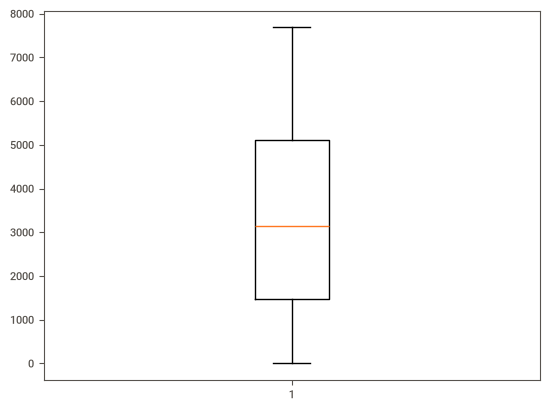

In [48]:
plt.boxplot( x=dataset["Mileage"])
plt.show()

In [39]:
dataset.describe()

,Price,Model,Prod. year,Category,Fuel type,Engine volume,Mileage,Cylinders,Gear box type
count,1.923700e+04,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000,19237.000000
mean,1.855593e+04,862.592348,2010.912824,6.265582,3.432396,41.462234,3364.284712,4.582991,0.536310
std,1.905813e+05,410.812287,5.668673,2.790570,1.807388,15.315334,2248.004443,1.199933,0.896607
min,1.000000e+00,0.000000,1939.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,5.331000e+03,537.000000,2009.000000,4.000000,2.000000,32.000000,1482.000000,4.000000,0.000000
50%,1.317200e+04,834.000000,2012.000000,7.000000,5.000000,36.000000,3140.000000,4.000000,0.000000
75%,2.207500e+04,1226.000000,2015.000000,9.000000,5.000000,46.000000,5104.000000,4.000000,1.000000
max,2.630750e+07,1589.000000,2020.000000,10.000000,6.000000,106.000000,7686.000000,16.000000,3.000000
